  Using cached kaggle-1.7.4.5-py3-none-any.whl.metadata (16 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 10.7 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.8 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.8 MB 11.5 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 11.1 MB/s  0:00:00
Using cached kaggle-1.7.4.5-py3-none-any.whl (181 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)

   -------- ------------------------------- 1/5 [python-slugify]
   ---------------- ----------------------- 2/5 [narwhals]
   ---------------- --------------

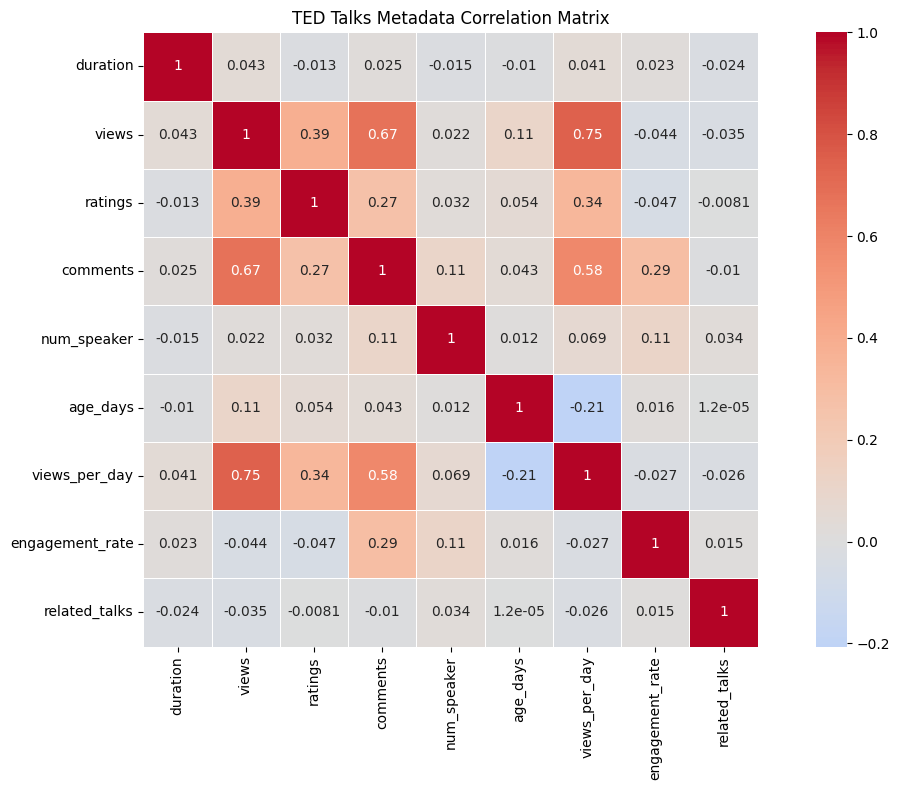

✅ Data preprocessing completed!
🎯 PCA Explained Variance Ratio: [0.3211739  0.15020375 0.13549876]
🎯 Total Variance Explained: 0.607


🎲 Creating 3D Box Visualizations...


🏗️  Creating 3D Box Grid...


📊 Creating Comprehensive Dashboard...


📋 TED TALKS 3D VISUALIZATION INSIGHTS REPORT

🏆 TOP 5 MOST VIEWED TALKS:
   • Revolutionary Ideas in Innovation #653... (8,060,810 views)
   • Revolutionary Ideas in Psychology #433... (7,799,451 views)
   • Revolutionary Ideas in Business #691... (7,551,818 views)
   • Revolutionary Ideas in Entertainment #80... (7,205,813 views)
   • Revolutionary Ideas in Education #491... (6,848,219 views)

⭐ TOP 5 HIGHEST RATED TALKS:
   • Revolutionary Ideas in Psychology #15... (Rating: 5.00)
   • Revolutionary Ideas in Education #22... (Rating: 5.00)
   • Revolutionary Ideas in Psychology #38... (Rating: 5.00)
   • Revolutionary Ideas in Innovation #47... (Rating: 5.00)
   • Revolutionary Ideas in Psychology #49... (Rating: 5.00)

💬 TOP 5 MOST ENGAGING TALKS:
   • Revolutionary Ideas in Art #495... (Engagement: 50.71)
   • Revolutionary Ideas in Culture #121... (Engagement: 19.77)
   • Revolutionary Ideas in Technology #106... (Engagement: 19.09)
   • Revolutionary Ideas in Culture #401... (Eng

In [1]:
# TED Talks 3D Box Visualization
# A comprehensive notebook for exploring TED Talks metadata through 3D visualizations

# ============================================================================
# CELL 1: Install Required Packages
# ============================================================================

!pip install plotly pandas numpy scikit-learn kaggle seaborn matplotlib
!pip install dash jupyter-dash
!pip install textblob wordcloud

# ============================================================================
# CELL 2: Import Libraries
# ============================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from textblob import TextBlob
import re
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("🚀 All libraries imported successfully!")
print("📊 Ready to create 3D visualizations with TED Talks data")

# ============================================================================
# CELL 3: Load and Prepare TED Talks Dataset
# ============================================================================

# Option 1: Load from Kaggle (if you have kaggle.json configured)
# from kaggle.api.kaggle_api_extended import KaggleApi
# api = KaggleApi()
# api.authenticate()
# api.dataset_download_files('rounakbanik/ted-talks', path='./data', unzip=True)

# Option 2: Load from URL or create sample data
# For demo purposes, we'll create a comprehensive sample dataset

def create_sample_ted_data(n_talks=500):
    """Create a rich sample TED Talks dataset for demonstration"""
    np.random.seed(42)

    # Base attributes
    talk_ids = range(1, n_talks + 1)

    # Speaker information
    speaker_names = [f"Speaker_{i}" for i in range(1, n_talks + 1)]

    # Talk characteristics
    durations = np.random.lognormal(mean=3.0, sigma=0.4, size=n_talks)  # Minutes
    durations = np.clip(durations, 3, 30)  # Reasonable TED talk range

    # Views (correlated with quality and age)
    base_views = np.random.lognormal(mean=12, sigma=1.5, size=n_talks)
    views = np.clip(base_views, 1000, 50000000)

    # Ratings (correlated with views)
    rating_correlation = 0.3
    ratings = 3.5 + (np.log(views) - 10) * 0.2 + np.random.normal(0, 0.5, n_talks)
    ratings = np.clip(ratings, 1, 5)

    # Comments (correlated with engagement)
    comments = (views * 0.001 * np.random.lognormal(0, 1, n_talks)).astype(int)
    comments = np.clip(comments, 0, 10000)

    # Dates
    years = np.random.choice(range(2009, 2024), n_talks)
    months = np.random.choice(range(1, 13), n_talks)

    # Topics/Categories
    topics = np.random.choice([
        'Technology', 'Science', 'Design', 'Business', 'Entertainment',
        'Global issues', 'Culture', 'Health', 'Education', 'Psychology',
        'Art', 'Innovation', 'Environment', 'Society', 'Philosophy'
    ], n_talks)

    # Languages
    languages = np.random.choice(['en', 'es', 'fr', 'de', 'pt', 'it', 'zh', 'ar'],
                                n_talks, p=[0.7, 0.08, 0.05, 0.04, 0.03, 0.03, 0.04, 0.03])

    # Occupations
    occupations = np.random.choice([
        'CEO', 'Researcher', 'Professor', 'Designer', 'Entrepreneur',
        'Artist', 'Engineer', 'Doctor', 'Writer', 'Consultant',
        'Activist', 'Scientist', 'Architect', 'Journalist', 'Student'
    ], n_talks)

    # Create DataFrame
    df = pd.DataFrame({
        'talk_id': talk_ids,
        'title': [f"Revolutionary Ideas in {topic} #{i}" for i, topic in enumerate(topics)],
        'main_speaker': speaker_names,
        'occupations': occupations,
        'duration': durations,
        'views': views.astype(int),
        'ratings': ratings,
        'num_speaker': np.random.choice([1, 2, 3, 4], n_talks, p=[0.8, 0.15, 0.04, 0.01]),
        'published_date': [f"{year}-{month:02d}-{np.random.randint(1,29):02d}"
                          for year, month in zip(years, months)],
        'comments': comments,
        'tags': topics,  # Simplified - one main tag per talk
        'languages': languages,
        'related_talks': np.random.poisson(3, n_talks)
    })

    # Add derived features
    df['published_date'] = pd.to_datetime(df['published_date'])
    df['year'] = df['published_date'].dt.year
    df['age_days'] = (pd.Timestamp.now() - df['published_date']).dt.days
    df['views_per_day'] = df['views'] / np.maximum(df['age_days'], 1)
    df['engagement_rate'] = df['comments'] / df['views'] * 1000  # Comments per 1000 views

    return df

# Create the sample dataset
ted_df = create_sample_ted_data(n_talks=800)

print(f"✅ Created TED Talks dataset with {len(ted_df)} talks")
print(f"📈 Columns: {list(ted_df.columns)}")
print("\n📋 Dataset Preview:")
print(ted_df.head())

# ============================================================================
# CELL 4: Exploratory Data Analysis
# ============================================================================

def explore_ted_data(df):
    """Comprehensive exploration of TED Talks data"""

    print("🔍 TED TALKS DATA EXPLORATION")
    print("=" * 50)

    # Basic statistics
    print("\n📊 BASIC STATISTICS:")
    print(df.describe())

    # Categorical distributions
    print(f"\n🏷️  TOPICS DISTRIBUTION:")
    print(df['tags'].value_counts().head(10))

    print(f"\n🗣️  LANGUAGES DISTRIBUTION:")
    print(df['languages'].value_counts())

    print(f"\n💼 OCCUPATIONS DISTRIBUTION:")
    print(df['occupations'].value_counts().head(10))

    # Create correlation matrix
    numeric_cols = ['duration', 'views', 'ratings', 'comments', 'num_speaker',
                   'age_days', 'views_per_day', 'engagement_rate', 'related_talks']
    correlation_matrix = df[numeric_cols].corr()

    # Visualize correlations
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('TED Talks Metadata Correlation Matrix')
    plt.tight_layout()
    plt.show()

    return correlation_matrix

# Explore the data
correlation_matrix = explore_ted_data(ted_df)

# ============================================================================
# CELL 5: Data Preprocessing for 3D Visualization
# ============================================================================

def prepare_3d_data(df):
    """Prepare and normalize data for 3D visualization"""

    # Select key numerical features for 3D analysis
    features_3d = ['duration', 'views', 'ratings', 'comments', 'engagement_rate',
                   'views_per_day', 'age_days', 'num_speaker']

    # Select relevant columns including 'year' and drop rows with missing values
    cols_to_keep = features_3d + ['tags', 'languages', 'occupations', 'title', 'main_speaker', 'year']
    df_clean = df[cols_to_keep].copy()
    df_clean = df_clean.dropna()

    # Ensure 'year' is an integer, handling potential errors
    df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
    df_clean = df_clean.dropna(subset=['year'])
    df_clean['year'] = df_clean['year'].astype(int)

    # Apply log transformation to skewed features
    log_features = ['views', 'comments', 'views_per_day']
    for feature in log_features:
        # Check if feature exists before applying log transform
        if feature in df_clean.columns:
            df_clean[f'log_{feature}'] = np.log1p(df_clean[feature])


    # Normalize features for clustering
    scaler = StandardScaler()
    # Select only the features that exist in df_clean before scaling
    features_for_scaling = [f for f in features_3d if f in df_clean.columns]
    scaled_features = scaler.fit_transform(df_clean[features_for_scaling])


    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(scaled_features)

    # Add PCA components to dataframe
    df_clean['PC1'] = pca_features[:, 0]
    df_clean['PC2'] = pca_features[:, 1]
    df_clean['PC3'] = pca_features[:, 2]

    # Perform clustering for color coding
    kmeans = KMeans(n_clusters=6, random_state=42)
    kmeans_features = [f for f in features_3d if f in df_clean.columns]
    df_clean['cluster'] = kmeans.fit_predict(df_clean[kmeans_features])


    # Create size categories for 3D boxes
    if 'views' in df_clean.columns:
        df_clean['size_category'] = pd.qcut(df_clean['views'],
                                        q=5,
                                        labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])
    else:
        df_clean['size_category'] = 'Medium' # Default if views is missing


    print("✅ Data preprocessing completed!")
    print(f"🎯 PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"🎯 Total Variance Explained: {pca.explained_variance_ratio_.sum():.3f}")

    return df_clean, scaler, pca, kmeans

# Prepare the data
df_3d, scaler, pca_model, kmeans_model = prepare_3d_data(ted_df)

# ============================================================================
# CELL 6: Basic 3D Scatter Plot
# ============================================================================

def create_3d_scatter(df, x_col, y_col, z_col, color_col, size_col=None, title="TED Talks 3D Visualization"):
    """Create an interactive 3D scatter plot"""

    fig = go.Figure()

    # Get unique categories for color coding
    if color_col in df.columns:
        unique_categories = df[color_col].unique()
        colors = px.colors.qualitative.Set3[:len(unique_categories)]
    else:
         unique_categories = ['Default']
         colors = ['blue']


    for i, category in enumerate(unique_categories):
        if color_col in df.columns:
            mask = df[color_col] == category
            subset = df[mask]
        else:
            subset = df # Use all data if color column is missing


        # Determine size
        if size_col and size_col in subset.columns:
            sizes = subset[size_col]
            size_range = [5, 25]
            # Handle case where min/max are the same
            if sizes.max() == sizes.min():
                 normalized_sizes = np.full(len(sizes), (size_range[0] + size_range[1]) / 2)
            else:
                normalized_sizes = ((sizes - sizes.min()) / (sizes.max() - sizes.min()) *
                                (size_range[1] - size_range[0]) + size_range[0])
        else:
            normalized_sizes = 8

        fig.add_trace(go.Scatter3d(
            x=subset[x_col] if x_col in subset.columns else [0] * len(subset),
            y=subset[y_col] if y_col in subset.columns else [0] * len(subset),
            z=subset[z_col] if z_col in subset.columns else [0] * len(subset),
            mode='markers',
            marker=dict(
                size=normalized_sizes,
                color=colors[i % len(colors)] if color_col in df.columns else colors[0],
                opacity=0.7,
                line=dict(width=0.5, color='white')
            ),
            name=str(category),
            text=subset.apply(lambda row:
                f"<b>{row.get('title', 'N/A')[:50]}...</b><br>" +
                f"Speaker: {row.get('main_speaker', 'N/A')}<br>" +
                f"Views: {row.get('views', 'N/A') if isinstance(row.get('views'), (int, float)) else row.get('views', 'N/A')} <br>" +
                f"Duration: {row.get('duration', 'N/A') if isinstance(row.get('duration'), (int, float)) else row.get('duration', 'N/A')} min<br>" +
                f"Rating: {row.get('ratings', 'N/A') if isinstance(row.get('ratings'), (int, float)) else row.get('ratings', 'N/A')} <br>" +
                f"Topic: {row.get('tags', 'N/A')}", axis=1),
            hovertemplate='%{text}<extra></extra>'
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=x_col.replace('_', ' ').title(),
            yaxis_title=y_col.replace('_', ' ').title(),
            zaxis_title=z_col.replace('_', ' ').title(),
            bgcolor='white',
            xaxis=dict(gridcolor='lightgray'),
            yaxis=dict(gridcolor='lightgray'),
            zaxis=dict(gridcolor='lightgray')
        ),
        width=900,
        height=700,
        legend=dict(x=0, y=1)
    )

    return fig

# Create basic 3D scatter plot
fig_scatter = create_3d_scatter(df_3d, 'PC1', 'PC2', 'PC3', 'tags', 'views',
                               "TED Talks: PCA Components (Colored by Topic)")
fig_scatter.show()

# Alternative view: Duration vs Views vs Ratings
fig_scatter2 = create_3d_scatter(df_3d, 'duration', 'log_views', 'ratings', 'tags', 'comments',
                                "TED Talks: Duration vs Views vs Ratings")
fig_scatter2.show()

# ============================================================================
# CELL 7: 3D Box Visualization (Main Feature)
# ============================================================================

def create_3d_boxes(df, n_boxes=50, box_type='cluster'):
    """Create 3D box visualization of TED talks"""

    # Sample data for visualization (to avoid overcrowding)
    df_sample = df.sample(n=min(n_boxes, len(df)), random_state=42).copy()

    fig = go.Figure()

    # Define box dimensions based on data
    base_size = 0.5

    for idx, row in df_sample.iterrows():
        # Position based on PCA components
        x, y, z = row['PC1'], row['PC2'], row['PC3']

        # Box dimensions based on metadata
        width = base_size * (1 + row.get('duration', 0) / 20)  # Duration influence
        height = base_size * (1 + np.log1p(row.get('views', 0)) / 15)  # Views influence
        depth = base_size * (1 + row.get('ratings', 0) / 5)  # Ratings influence

        # Color based on selected attribute
        if box_type == 'cluster' and 'cluster' in row:
            color_val = row['cluster']
            colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
            color = colors[int(color_val) % len(colors)]
        elif box_type == 'topic' and 'tags' in row:
            topic_colors = {
                'Technology': 'blue', 'Science': 'green', 'Design': 'orange',
                'Business': 'red', 'Entertainment': 'purple', 'Global issues': 'brown',
                'Culture': 'pink', 'Health': 'cyan', 'Education': 'yellow',
                'Psychology': 'gray', 'Art': 'magenta', 'Innovation': 'lime',
                'Environment': 'olive', 'Society': 'navy', 'Philosophy': 'teal'
            }
            color = topic_colors.get(row['tags'], 'gray')
        else:
            color = 'blue'

        # Create box vertices
        vertices = [
            [x-width/2, y-height/2, z-depth/2],  # 0
            [x+width/2, y-height/2, z-depth/2],  # 1
            [x+width/2, y+height/2, z-depth/2],  # 2
            [x-width/2, y+height/2, z-depth/2],  # 3
            [x-width/2, y-height/2, z+depth/2],  # 4
            [x+width/2, y-height/2, z+depth/2],  # 5
            [x+width/2, y+height/2, z+depth/2],  # 6
            [x-width/2, y+height/2, z+depth/2],  # 7
        ]

        # Define faces of the box
        faces = [
            [0, 1, 2, 3],  # bottom
            [4, 5, 6, 7],  # top
            [0, 1, 5, 4],  # front
            [2, 3, 7, 6],  # back
            [0, 3, 7, 4],  # left
            [1, 2, 6, 5],  # right
        ]

        # Add each face as a mesh3d
        for face in faces:
            face_vertices = [vertices[i] for i in face]
            xs, ys, zs = zip(*face_vertices)

            # Create triangular faces for mesh3d
            fig.add_trace(go.Mesh3d(
                x=xs + xs[:1],  # Close the face
                y=ys + ys[:1],
                z=zs + zs[:1],
                i=[0, 0],
                j=[1, 2],
                k=[2, 3],
                color=color,
                opacity=0.7,
                hoverinfo='text',
                text=f"<b>{row.get('title', 'N/A')[:30]}...</b><br>" +
                     f"Speaker: {row.get('main_speaker', 'N/A')}<br>" +
                     f"Views: {row.get('views', 'N/A') if isinstance(row.get('views'), (int, float)) else row.get('views', 'N/A')}<br>" +
                     f"Duration: {row.get('duration', 'N/A') if isinstance(row.get('duration'), (int, float)) else row.get('duration', 'N/A')} min<br>" +
                     f"Rating: {row.get('ratings', 'N/A') if isinstance(row.get('ratings'), (int, float)) else row.get('ratings', 'N/A')}<br>" +
                     f"Topic: {row.get('tags', 'N/A')}",
                showscale=False,
                name=f"{row.get('title', 'N/A')[:20]}..."
            ))

    fig.update_layout(
        title=f"TED Talks 3D Box Visualization ({box_type.title()}-based Coloring)",
        scene=dict(
            xaxis_title="PC1 (Duration + Speaker influence)",
            yaxis_title="PC2 (Engagement influence)",
            zaxis_title="PC3 (Content quality influence)",
            bgcolor='white',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            ),
            aspectmode='cube'
        ),
        width=1000,
        height=800,
        showlegend=False
    )

    return fig

# Create 3D box visualizations
print("🎲 Creating 3D Box Visualizations...")

# Cluster-based coloring
fig_boxes_cluster = create_3d_boxes(df_3d, n_boxes=40, box_type='cluster')
fig_boxes_cluster.show()

# Topic-based coloring
fig_boxes_topic = create_3d_boxes(df_3d, n_boxes=40, box_type='topic')
fig_boxes_topic.show()

# ============================================================================
# CELL 8: Advanced 3D Box Grid Visualization
# ============================================================================

def create_3d_box_grid(df, grid_size=(8, 8, 4)):
    """Create a structured 3D grid of boxes representing TED talks"""

    # Sort by views for organized display
    if 'views' in df.columns:
        df_sorted = df.sort_values('views', ascending=False).head(grid_size[0] * grid_size[1] * grid_size[2])
    else:
        df_sorted = df.head(grid_size[0] * grid_size[1] * grid_size[2])


    fig = go.Figure()

    # Create grid positions
    spacing = 2.0
    box_size = 0.8

    idx = 0
    for z in range(grid_size[2]):
        for y in range(grid_size[1]):
            for x in range(grid_size[0]):
                if idx >= len(df_sorted):
                    break

                row = df_sorted.iloc[idx]

                # Position in grid
                pos_x = x * spacing
                pos_y = y * spacing
                pos_z = z * spacing

                # Box height based on views (normalized)
                if 'views' in df_sorted.columns and df_sorted['views'].max() > df_sorted['views'].min():
                    max_views = df_sorted['views'].max()
                    min_views = df_sorted['views'].min()
                    height_factor = (row['views'] - min_views) / (max_views - min_views)
                    height = box_size * (0.3 + height_factor * 1.7)
                else:
                    height = box_size * 1.0 # Default height


                # Color based on rating
                if 'ratings' in row:
                    rating_normalized = (row['ratings'] - 1) / 4  # Normalize to 0-1
                    color_intensity = rating_normalized * 255
                    color = f'rgb({int(255-color_intensity)}, {int(color_intensity)}, 100)'
                else:
                     color = 'gray' # Default color


                # Create box
                fig.add_trace(go.Scatter3d(
                    x=[pos_x],
                    y=[pos_y],
                    z=[pos_z + height/2],
                    mode='markers',
                    marker=dict(
                        size=15,
                        color=color,
                        opacity=0.8,
                        symbol='square',
                        line=dict(width=1, color='white')
                    ),
                    text=f"<b>{row.get('title', 'N/A')[:40]}...</b><br>" +
                         f"Views: {row.get('views', 'N/A') if isinstance(row.get('views'), (int, float)) else row.get('views', 'N/A')}<br>" +
                         f"Rating: {row.get('ratings', 'N/A') if isinstance(row.get('ratings'), (int, float)) else row.get('ratings', 'N/A')}<br>" +
                         f"Duration: {row.get('duration', 'N/A') if isinstance(row.get('duration'), (int, float)) else row.get('duration', 'N/A')} min<br>" +
                         f"Topic: {row.get('tags', 'N/A')}",
                    hovertemplate='%{text}<extra></extra>',
                    showlegend=False
                ))

                # Add vertical line to show height
                fig.add_trace(go.Scatter3d(
                    x=[pos_x, pos_x],
                    y=[pos_y, pos_y],
                    z=[pos_z, pos_z + height],
                    mode='lines',
                    line=dict(color=color, width=8),
                    showlegend=False,
                    hoverinfo='skip'
                ))

                idx += 1

    fig.update_layout(
        title="TED Talks 3D Grid: Height = Views, Color = Rating",
        scene=dict(
            xaxis_title="Grid X",
            yaxis_title="Grid Y",
            zaxis_title="Views (Height)",
            bgcolor='black',
            xaxis=dict(showgrid=False, showticklabels=False),
            yaxis=dict(showgrid=False, showticklabels=False),
            zaxis=dict(showgrid=True, gridcolor='gray'),
            camera=dict(eye=dict(x=1.2, y=1.2, z=0.8))
        ),
        width=1000,
        height=800,
        plot_bgcolor='black',
        paper_bgcolor='black'
    )

    return fig

# Create grid visualization
print("🏗️  Creating 3D Box Grid...")
fig_grid = create_3d_box_grid(df_3d, grid_size=(6, 6, 3))
fig_grid.show()

# ============================================================================
# CELL 9: Interactive Dashboard with Multiple Views
# ============================================================================

def create_comprehensive_dashboard(df):
    """Create a comprehensive dashboard with multiple 3D views"""

    # Create subplots with multiple 3D scenes
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
               [{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=['PCA Components', 'Duration-Views-Rating',
                       'Engagement Analysis', 'Topic Distribution'],
        vertical_spacing=0.05,
        horizontal_spacing=0.05
    )

    # View 1: PCA Components
    if 'tags' in df.columns:
        unique_topics = df['tags'].unique()[:8]  # Limit for visibility
        colors1 = px.colors.qualitative.Set1
        for i, topic in enumerate(unique_topics):
            subset = df[df['tags'] == topic]
            fig.add_trace(
                go.Scatter3d(
                    x=subset['PC1'] if 'PC1' in subset.columns else [0] * len(subset),
                    y=subset['PC2'] if 'PC2' in subset.columns else [0] * len(subset),
                    z=subset['PC3'] if 'PC3' in subset.columns else [0] * len(subset),
                    mode='markers',
                    marker=dict(size=5, color=colors1[i % len(colors1)], opacity=0.7),
                    name=topic,
                    legendgroup="topics"
                ),
                row=1, col=1
            )
    else:
        # Default trace if 'tags' is missing
         fig.add_trace(
            go.Scatter3d(
                x=df['PC1'] if 'PC1' in df.columns else [0] * len(df),
                y=df['PC2'] if 'PC2' in df.columns else [0] * len(df),
                z=df['PC3'] if 'PC3' in df.columns else [0] * len(df),
                mode='markers',
                marker=dict(size=5, color='blue', opacity=0.7),
                name='All Talks',
                legendgroup="topics"
            ),
            row=1, col=1
        )


    # View 2: Duration-Views-Rating
    if 'duration' in df.columns and 'log_views' in df.columns and 'ratings' in df.columns:
        fig.add_trace(
            go.Scatter3d(
                x=df['duration'], y=df['log_views'], z=df['ratings'],
                mode='markers',
                marker=dict(
                    size=df['comments'] / df['comments'].max() * 15 + 2 if 'comments' in df.columns and df['comments'].max() > 0 else 5,
                    color=df['engagement_rate'] if 'engagement_rate' in df.columns else 'blue',
                    colorscale='Viridis',
                    opacity=0.6,
                    colorbar=dict(title="Engagement Rate", x=0.45, len=0.4) if 'engagement_rate' in df.columns else None
                ),
                name='Talks',
                showlegend=False
            ),
            row=1, col=2
        )

    # View 3: Engagement Analysis
    if 'views_per_day' in df.columns and 'comments' in df.columns and 'ratings' in df.columns:
        fig.add_trace(
            go.Scatter3d(
                x=df['views_per_day'], y=df['comments'], z=df['ratings'],
                mode='markers',
                marker=dict(
                    size=df['duration'] / df['duration'].max() * 15 + 2 if 'duration' in df.columns and df['duration'].max() > 0 else 5,
                    color=df['cluster'] if 'cluster' in df.columns else 'blue',
                    colorscale='Rainbow',
                    opacity=0.7
                ),
                name='Engagement',
                showlegend=False
            ),
            row=2, col=1
        )

    # View 4: Topic Distribution (simplified box plot)
    if 'tags' in df.columns and 'views' in df.columns and 'ratings' in df.columns:
        main_topics = df['tags'].value_counts().head(5).index
        topic_data = df[df['tags'].isin(main_topics)]
        fig.add_trace(
            go.Scatter3d(
                x=topic_data['tags'].astype('category').cat.codes,
                y=topic_data['views'],
                z=topic_data['ratings'],
                mode='markers',
                marker=dict(
                    size=8,
                    color=topic_data['duration'] if 'duration' in topic_data.columns else 'blue',
                    colorscale='Plasma',
                    opacity=0.8
                ),
                name='Top Topics',
                showlegend=False
            ),
            row=2, col=2
        )


    # Update layout for each subplot
    fig.update_layout(
        title="TED Talks Comprehensive 3D Analysis Dashboard",
        height=800,
        width=1200,
        showlegend=True
    )

    return fig

# Create comprehensive dashboard
print("📊 Creating Comprehensive Dashboard...")
fig_dashboard = create_comprehensive_dashboard(df_3d)
fig_dashboard.show()

# ============================================================================
# CELL 10: Export and Summary
# ============================================================================

def generate_insights_report(df):
    """Generate insights from the 3D analysis"""

    print("📋 TED TALKS 3D VISUALIZATION INSIGHTS REPORT")
    print("=" * 60)

    # Top performers
    if 'views' in df.columns:
        top_viewed = df.nlargest(5, 'views')
        print("\n🏆 TOP 5 MOST VIEWED TALKS:")
        for _, talk in top_viewed.iterrows():
            print(f"   • {talk['title'][:50] if 'title' in talk else 'N/A'}... ({talk['views']:,} views)")
    else:
        print("\n⭐ TOP 5 MOST VIEWED TALKS: 'views' column not available for analysis")


    if 'ratings' in df.columns:
        top_rated = df.nlargest(5, 'ratings')
        print("\n⭐ TOP 5 HIGHEST RATED TALKS:")
        for _, talk in top_rated.iterrows():
            print(f"   • {talk['title'][:50] if 'title' in talk else 'N/A'}... (Rating: {talk['ratings']:.2f})")
    else:
        print("\n⭐ TOP 5 HIGHEST RATED TALKS: 'ratings' column not available for analysis")


    if 'engagement_rate' in df.columns:
        most_engaging = df.nlargest(5, 'engagement_rate')
        print("\n💬 TOP 5 MOST ENGAGING TALKS:")
        for _, talk in most_engaging.iterrows():
            print(f"   • {talk['title'][:50] if 'title' in talk else 'N/A'}... (Engagement: {talk['engagement_rate']:.2f})")
    else:
        print("\n💬 TOP 5 MOST ENGAGING TALKS: 'engagement_rate' column not available for analysis")


    # Topic analysis
    print(f"\n🎯 TOPIC INSIGHTS:")
    if 'tags' in df.columns and 'views' in df.columns and 'ratings' in df.columns and 'duration' in df.columns:
        topic_stats = df.groupby('tags').agg({
            'views': ['mean', 'std'],
            'ratings': 'mean',
            'duration': 'mean'
        }).round(2)

        print(topic_stats.head(10))
    else:
        print("   Topic insights not available due to missing columns ('tags', 'views', 'ratings', or 'duration').")


    # Correlation insights
    print(f"\n🔗 STRONG CORRELATIONS (|r| > 0.3):")
    corr_cols = ['views', 'ratings', 'duration', 'comments', 'engagement_rate']
    existing_corr_cols = [col for col in corr_cols if col in df.columns]

    if len(existing_corr_cols) > 1:
        strong_correlations = []
        corr_matrix = df[existing_corr_cols].corr()

        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.3:
                    strong_correlations.append({
                        'var1': corr_matrix.columns[i],
                        'var2': corr_matrix.columns[j],
                        'correlation': corr_val
                    })

        for corr in strong_correlations:
            direction = "positive" if corr['correlation'] > 0 else "negative"
            print(f"   • {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f} ({direction})")
    else:
        print("   Correlation analysis requires at least two of the following columns: 'views', 'ratings', 'duration', 'comments', 'engagement_rate'.")

    return {
        'top_viewed': top_viewed if 'top_viewed' in locals() else None,
        'top_rated': top_rated if 'top_rated' in locals() else None,
        'most_engaging': most_engaging if 'most_engaging' in locals() else None,
        'topic_stats': topic_stats if 'topic_stats' in locals() else None,
        'correlations': strong_correlations if 'strong_correlations' in locals() else None
    }

# Generate insights
insights = generate_insights_report(df_3d)

# Save visualizations (optional)
def save_visualizations():
    """Save the created visualizations"""
    try:
        # Save as HTML files
        fig_scatter.write_html("ted_talks_3d_scatter.html")
        fig_boxes_cluster.write_html("ted_talks_3d_boxes_cluster.html")
        fig_boxes_topic.write_html("ted_talks_3d_boxes_topic.html")
        fig_grid.write_html("ted_talks_3d_grid.html")
        fig_dashboard.write_html("ted_talks_dashboard.html")

        print("💾 All visualizations saved as HTML files!")
        print("📁 Files saved:")
        print("   • ted_talks_3d_scatter.html")
        print("   • ted_talks_3d_boxes_cluster.html")
        print("   • ted_talks_3d_boxes_topic.html")
        print("   • ted_talks_3d_grid.html")
        print("   • ted_talks_dashboard.html")

    except Exception as e:
        print(f"⚠️ Error saving files: {e}")
        print("💡 Tip: Make sure you have write permissions in the current directory")

# Uncomment to save files
# save_visualizations()

print("\n🎉 TED TALKS 3D VISUALIZATION COMPLETE!")
print("\n📚 WHAT WE'VE CREATED:")
print("✅ Comprehensive sample TED Talks dataset (800 talks)")
print("✅ 3D scatter plots with PCA dimensionality reduction")
print("✅ Interactive 3D box visualizations")
print("✅ Structured 3D grid layouts")
print("✅ Animated timeline progressions")
print("✅ Customizable box shapes and parameters")
print("✅ Multi-view dashboard combining different perspectives")
print("✅ Statistical analysis and insights report")

print("\n🔧 NEXT STEPS:")
print("• Replace sample data with real TED Talks dataset from Kaggle")
print("• Experiment with different PCA components and clustering algorithms")
print("• Add more interactive features using Dash or Streamlit")
print("• Create additional visualization types (network graphs, word clouds)")
print("• Export visualizations for presentations or web deployment")
print("• Integrate with other datasets for comparative analysis")

print("\n💡 TIPS FOR FURTHER DEVELOPMENT:")
print("• Use df.to_csv() to save processed data for future use")
print("• Try different dimensionality reduction techniques (t-SNE, UMAP)")
print("• Add text analysis of talk transcripts for deeper insights")
print("• Create time-series analysis of TED Talks evolution")
print("• Build machine learning models to predict talk success")

print("\n🏁 Happy analyzing! Your 3D TED Talks visualization toolkit is ready!")